# Tutorial 06 — Transfer Learning: Predicting with Pretrained Models

## Objective

This notebook implements **Tutorial 06: Predicting Top 5 Labels with Pretrained Models** using PyTorch.

The tutorial covers:

- Loading pretrained models
- VGG16 and ResNet50 top-5 ImageNet predictions
- AlexNet, ResNet101, and MobileNet prediction experiments
- Using a custom dataset for transfer learning
- Training pretrained models on a 2-class custom dataset
- Comparing transfer learning architectures

Custom dataset used:

- Furina
- Ororon

Expected folder structure:

```text
Tutorial_06/
├── tutorial_06_transfer_learning.ipynb
├── dataset/
│   ├── furina/
│   └── ororon/
└── images/
```


## 1. Import Required Libraries

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Dataset Path

Place the `dataset` folder in the same folder as this notebook.

Expected structure:

```text
dataset/
├── furina/
│   ├── furina_001.png
│   ├── furina_002.png
│   └── ...
└── ororon/
    ├── ororon_001.png
    ├── ororon_002.png
    └── ...
```

The class labels come from the folder names.


In [2]:
DATA_DIR = "dataset"

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        "Dataset folder not found. Place the 'dataset' folder in the same directory as this notebook. "
        "Expected: dataset/furina and dataset/ororon"
    )

print("Dataset folder found:", DATA_DIR)
print("Classes/folders:", sorted(os.listdir(DATA_DIR)))


Dataset folder found: dataset
Classes/folders: ['furina', 'ororon']


## 3. Load Dataset for Inspection

For classification, PyTorch `ImageFolder` automatically reads class names from folder names.

So:

```text
dataset/furina  -> class furina
dataset/ororon  -> class ororon
```


In [3]:
inspect_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

inspect_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=inspect_transform
)

class_names = inspect_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Class to index:", inspect_dataset.class_to_idx)
print("Total images:", len(inspect_dataset))


Classes: ['furina', 'ororon']
Class to index: {'furina': 0, 'ororon': 1}
Total images: 150


## 4. Visualize Sample Images

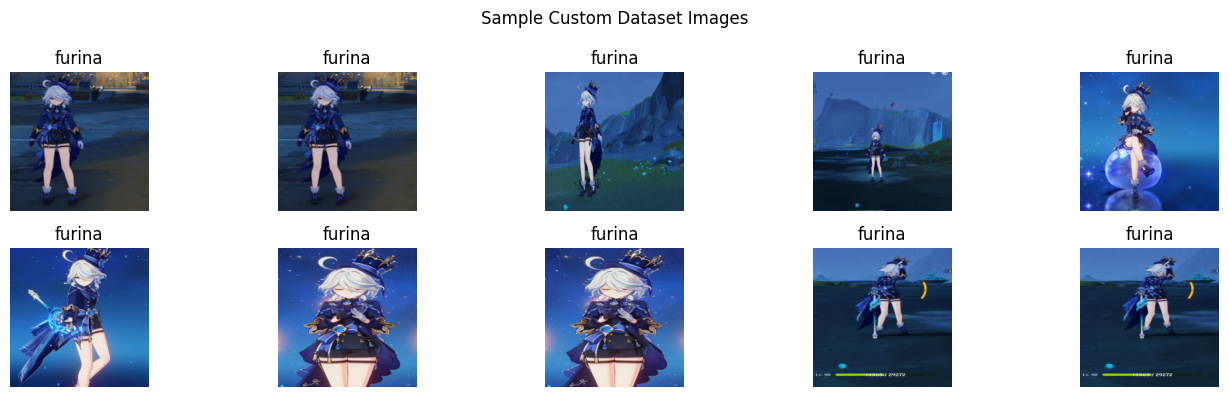

In [4]:
def show_dataset_samples(dataset, class_names, n_images=10):
    plt.figure(figsize=(14, 4))

    for i in range(min(n_images, len(dataset))):
        image, label = dataset[i]
        image_np = image.permute(1, 2, 0).numpy()

        plt.subplot(2, 5, i + 1)
        plt.imshow(image_np)
        plt.title(class_names[label])
        plt.axis("off")

    plt.suptitle("Sample Custom Dataset Images")
    plt.tight_layout()
    plt.savefig("images/tutorial_06_custom_dataset_samples.png", dpi=300, bbox_inches="tight")
    plt.show()


show_dataset_samples(inspect_dataset, class_names, n_images=10)


# Part A — Top-5 Predictions with Pretrained ImageNet Models

The first part of the tutorial uses pretrained models to predict the top-5 ImageNet labels for an input image.

Important note:

The pretrained models were trained on ImageNet.  
They do not know the custom class names `furina` and `ororon`.

So the top-5 predictions may be unrelated labels, but this still demonstrates how pretrained model prediction works.


## 5. Select an Image for Top-5 Prediction

Image used for top-5 prediction:
dataset\furina\furina_001.png


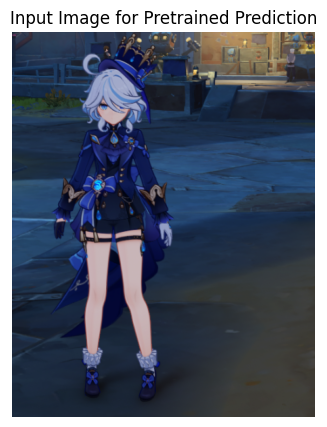

In [5]:
# If you want to use a specific image, write the path here.
# Example: TEST_IMAGE_PATH = "dataset/furina/furina_001.png"
TEST_IMAGE_PATH = None

if TEST_IMAGE_PATH is None:
    TEST_IMAGE_PATH = inspect_dataset.samples[0][0]

print("Image used for top-5 prediction:")
print(TEST_IMAGE_PATH)

input_image = Image.open(TEST_IMAGE_PATH).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(input_image)
plt.title("Input Image for Pretrained Prediction")
plt.axis("off")
plt.savefig("images/tutorial_06_input_image_for_prediction.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Load Pretrained Models

In [6]:
pretrained_model_configs = {
    "VGG16": {
        "model_fn": models.vgg16,
        "weights": models.VGG16_Weights.DEFAULT
    },
    "ResNet50": {
        "model_fn": models.resnet50,
        "weights": models.ResNet50_Weights.DEFAULT
    },
    "AlexNet": {
        "model_fn": models.alexnet,
        "weights": models.AlexNet_Weights.DEFAULT
    },
    "ResNet101": {
        "model_fn": models.resnet101,
        "weights": models.ResNet101_Weights.DEFAULT
    },
    "MobileNet_V3_Large": {
        "model_fn": models.mobilenet_v3_large,
        "weights": models.MobileNet_V3_Large_Weights.DEFAULT
    }
}

pretrained_models = {}

for model_name, config in pretrained_model_configs.items():
    print("Loading:", model_name)
    model = config["model_fn"](weights=config["weights"])
    model = model.to(device)
    model.eval()
    pretrained_models[model_name] = model

print("All pretrained models loaded.")


Loading: VGG16
Loading: ResNet50
Loading: AlexNet


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\mumer/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100.0%


Loading: ResNet101


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to C:\Users\mumer/.cache\torch\hub\checkpoints\resnet101-cd907fc2.pth
100.0%


Loading: MobileNet_V3_Large


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\mumer/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth
100.0%

All pretrained models loaded.


## 7. Make Top-5 Predictions

In [7]:
def get_top5_predictions(model, weights, image):
    preprocess = weights.transforms()
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)

    top5_probabilities, top5_indices = torch.topk(probabilities, 5)

    categories = weights.meta["categories"]

    results = []

    for prob, idx in zip(top5_probabilities[0], top5_indices[0]):
        results.append({
            "Label": categories[idx.item()],
            "Probability": prob.item()
        })

    return results


top5_results = []

for model_name, config in pretrained_model_configs.items():
    model = pretrained_models[model_name]
    weights = config["weights"]

    predictions = get_top5_predictions(model, weights, input_image)

    print("\nTop-5 predictions for", model_name)

    for rank, pred in enumerate(predictions, start=1):
        print(f"{rank}. {pred['Label']} - {pred['Probability'] * 100:.2f}%")

        top5_results.append({
            "Model": model_name,
            "Rank": rank,
            "Label": pred["Label"],
            "Probability": pred["Probability"]
        })

top5_df = pd.DataFrame(top5_results)
top5_df



Top-5 predictions for VGG16
1. sarong - 52.12%
2. trench coat - 3.36%
3. kimono - 3.17%
4. maillot - 2.71%
5. maillot tank suit - 2.31%

Top-5 predictions for ResNet50
1. kimono - 4.79%
2. military uniform - 4.62%
3. crash helmet - 3.74%
4. mask - 2.23%
5. miniskirt - 2.05%

Top-5 predictions for AlexNet
1. scuba diver - 10.69%
2. paddle - 8.55%
3. racket - 3.79%
4. snorkel - 3.14%
5. bathing cap - 3.07%

Top-5 predictions for ResNet101
1. scuba diver - 76.03%
2. knee pad - 1.11%
3. wreck - 1.01%
4. coral reef - 0.95%
5. breastplate - 0.65%

Top-5 predictions for MobileNet_V3_Large
1. scuba diver - 13.05%
2. parachute - 7.42%
3. knee pad - 5.07%
4. gasmask - 5.04%
5. oxygen mask - 3.87%


,Model,Rank,Label,Probability
0,VGG16,1,sarong,0.521205
1,VGG16,2,trench coat,0.033631
2,VGG16,3,kimono,0.031744
3,VGG16,4,maillot,0.027108
4,VGG16,5,maillot tank suit,0.023142
5,ResNet50,1,kimono,0.047922
6,ResNet50,2,military uniform,0.046151
7,ResNet50,3,crash helmet,0.037376
8,ResNet50,4,mask,0.022251
9,ResNet50,5,miniskirt,0.020466


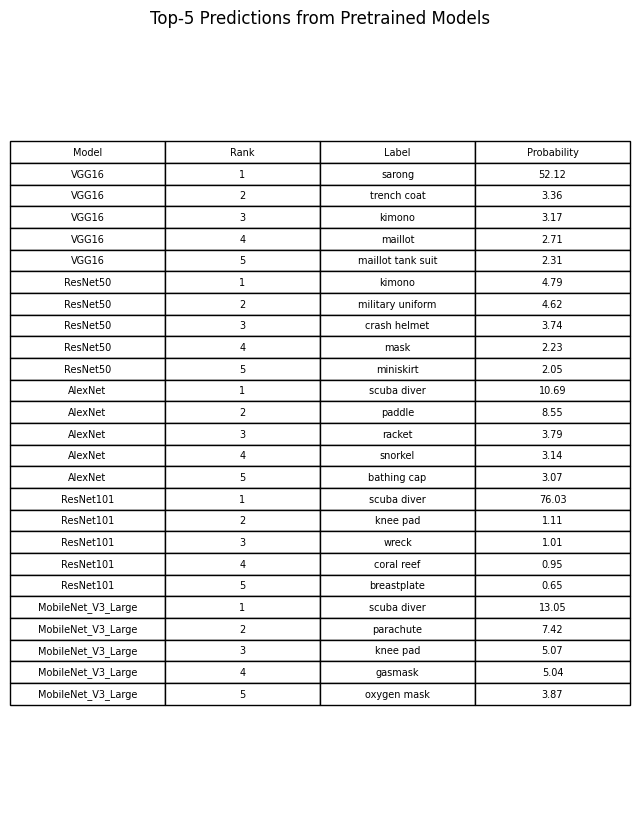

In [8]:
def save_dataframe_as_image(df, filename, title=None, fontsize=8):
    fig_width = max(8, len(df.columns) * 2.0)
    fig_height = max(2.5, len(df) * 0.35 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.3)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


top5_image_df = top5_df.copy()
top5_image_df["Probability"] = (top5_image_df["Probability"] * 100).round(2)

save_dataframe_as_image(
    top5_image_df,
    "images/tutorial_06_top5_pretrained_predictions.png",
    title="Top-5 Predictions from Pretrained Models",
    fontsize=7
)


# Part B — Transfer Learning on Custom Dataset

The second task asks to use transfer learning on a dataset.

Here, the custom Furina/Ororon dataset is used.

The pretrained models are modified so that the final classification layer predicts only two classes:

```text
furina
ororon
```


## 8. Create Train / Validation / Test Splits

In [9]:
# ImageNet normalization is used because pretrained models expect ImageNet-style input.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop((224, 224), scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

train_full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
eval_full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)

dataset_size = len(train_full_dataset)
indices = np.arange(dataset_size)

np.random.seed(SEED)
np.random.shuffle(indices)

train_end = int(0.70 * dataset_size)
val_end = int(0.85 * dataset_size)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

train_dataset = Subset(train_full_dataset, train_indices)
val_dataset = Subset(eval_full_dataset, val_indices)
test_dataset = Subset(eval_full_dataset, test_indices)

batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Total images:", dataset_size)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Classes:", class_names)


Total images: 150
Training images: 105
Validation images: 22
Test images: 23
Classes: ['furina', 'ororon']


## 9. Build Transfer Learning Models

The pretrained feature extractor is frozen.  
Only the final classifier layer is trained.

This makes training faster and reduces overfitting on a small dataset.


In [10]:
def freeze_all_parameters(model):
    for param in model.parameters():
        param.requires_grad = False


def build_transfer_model(model_name, num_classes):
    model_name = model_name.lower()

    if model_name == "vgg16":
        weights = models.VGG16_Weights.DEFAULT
        model = models.vgg16(weights=weights)
        freeze_all_parameters(model)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        freeze_all_parameters(model)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "alexnet":
        weights = models.AlexNet_Weights.DEFAULT
        model = models.alexnet(weights=weights)
        freeze_all_parameters(model)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    elif model_name == "resnet101":
        weights = models.ResNet101_Weights.DEFAULT
        model = models.resnet101(weights=weights)
        freeze_all_parameters(model)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "mobilenet":
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        model = models.mobilenet_v3_large(weights=weights)
        freeze_all_parameters(model)
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError("Unknown model name.")

    return model.to(device)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_total_parameters(model):
    return sum(p.numel() for p in model.parameters())


## 10. Training and Evaluation Functions

In [11]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate_model(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


def train_transfer_model(model, train_loader, val_loader, epochs=5, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc * 100:.2f}% | "
            f"Val Acc: {val_acc * 100:.2f}%"
        )

    total_time = time.time() - start_time

    return history, total_time


def plot_training_history(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def get_predictions(model, data_loader):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_predictions)


## 11. Train Transfer Learning Models

Models trained:

- VGG16
- ResNet50
- AlexNet
- ResNet101
- MobileNet V3 Large

If training is too slow, reduce `TRANSFER_EPOCHS` or remove heavy models from `models_to_train`.



Training model: vgg16
Total parameters: 134268738
Trainable parameters: 8194
Epoch 1/5 | Train Loss: 0.7347 | Val Loss: 0.5080 | Train Acc: 58.10% | Val Acc: 72.73%
Epoch 2/5 | Train Loss: 0.3053 | Val Loss: 0.3331 | Train Acc: 87.62% | Val Acc: 95.45%
Epoch 3/5 | Train Loss: 0.2651 | Val Loss: 0.2941 | Train Acc: 88.57% | Val Acc: 90.91%
Epoch 4/5 | Train Loss: 0.2192 | Val Loss: 0.3189 | Train Acc: 94.29% | Val Acc: 86.36%
Epoch 5/5 | Train Loss: 0.2166 | Val Loss: 0.3254 | Train Acc: 90.48% | Val Acc: 86.36%
Test Loss: 0.3391
Test Accuracy: 82.61 %


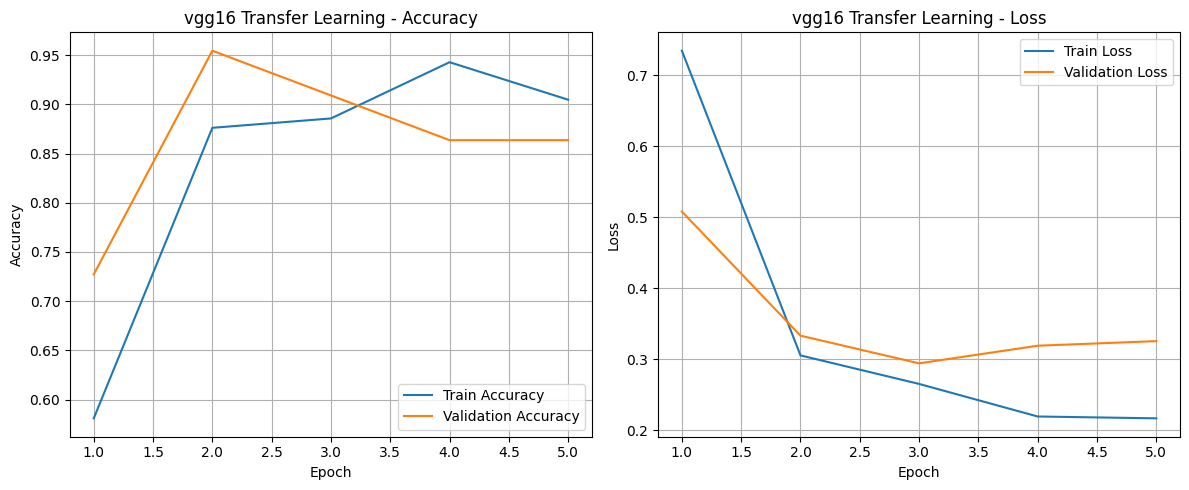


Training model: resnet50
Total parameters: 23512130
Trainable parameters: 4098
Epoch 1/5 | Train Loss: 0.6589 | Val Loss: 0.5758 | Train Acc: 61.90% | Val Acc: 86.36%
Epoch 2/5 | Train Loss: 0.5432 | Val Loss: 0.4823 | Train Acc: 84.76% | Val Acc: 95.45%
Epoch 3/5 | Train Loss: 0.4572 | Val Loss: 0.4278 | Train Acc: 90.48% | Val Acc: 95.45%
Epoch 4/5 | Train Loss: 0.3915 | Val Loss: 0.3955 | Train Acc: 95.24% | Val Acc: 100.00%
Epoch 5/5 | Train Loss: 0.3803 | Val Loss: 0.3673 | Train Acc: 92.38% | Val Acc: 100.00%
Test Loss: 0.3863
Test Accuracy: 95.65 %


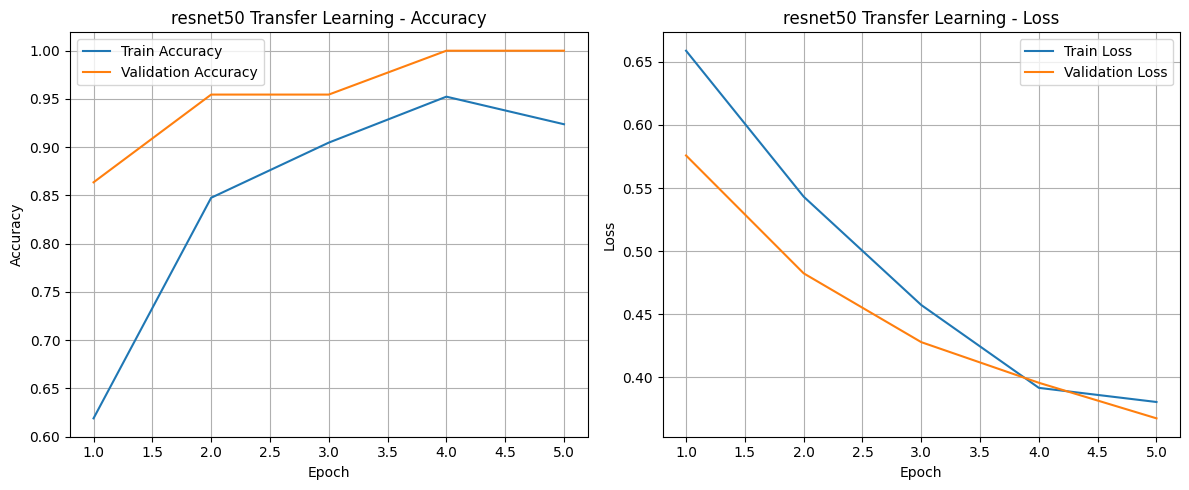


Training model: alexnet
Total parameters: 57012034
Trainable parameters: 8194
Epoch 1/5 | Train Loss: 0.6282 | Val Loss: 0.3124 | Train Acc: 67.62% | Val Acc: 86.36%
Epoch 2/5 | Train Loss: 0.2405 | Val Loss: 0.3558 | Train Acc: 90.48% | Val Acc: 90.91%
Epoch 3/5 | Train Loss: 0.1643 | Val Loss: 0.3047 | Train Acc: 94.29% | Val Acc: 86.36%
Epoch 4/5 | Train Loss: 0.1295 | Val Loss: 0.2495 | Train Acc: 95.24% | Val Acc: 86.36%
Epoch 5/5 | Train Loss: 0.0794 | Val Loss: 0.2131 | Train Acc: 98.10% | Val Acc: 90.91%
Test Loss: 0.1704
Test Accuracy: 91.3 %


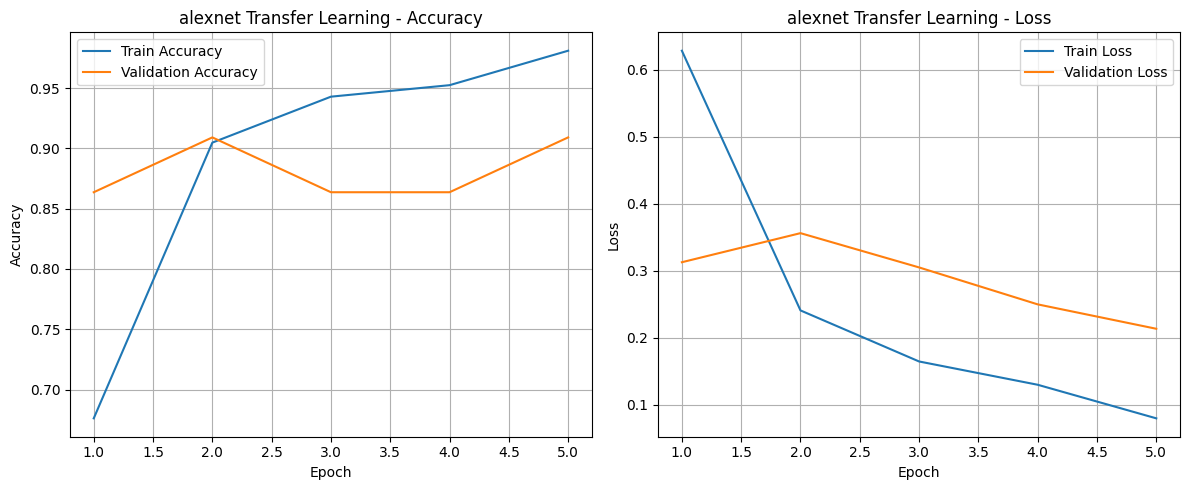


Training model: resnet101
Total parameters: 42504258
Trainable parameters: 4098
Epoch 1/5 | Train Loss: 0.6547 | Val Loss: 0.5798 | Train Acc: 60.00% | Val Acc: 86.36%
Epoch 2/5 | Train Loss: 0.5522 | Val Loss: 0.5155 | Train Acc: 72.38% | Val Acc: 90.91%
Epoch 3/5 | Train Loss: 0.4840 | Val Loss: 0.4351 | Train Acc: 79.05% | Val Acc: 95.45%
Epoch 4/5 | Train Loss: 0.3808 | Val Loss: 0.3754 | Train Acc: 92.38% | Val Acc: 95.45%
Epoch 5/5 | Train Loss: 0.4078 | Val Loss: 0.3328 | Train Acc: 85.71% | Val Acc: 95.45%
Test Loss: 0.34
Test Accuracy: 95.65 %


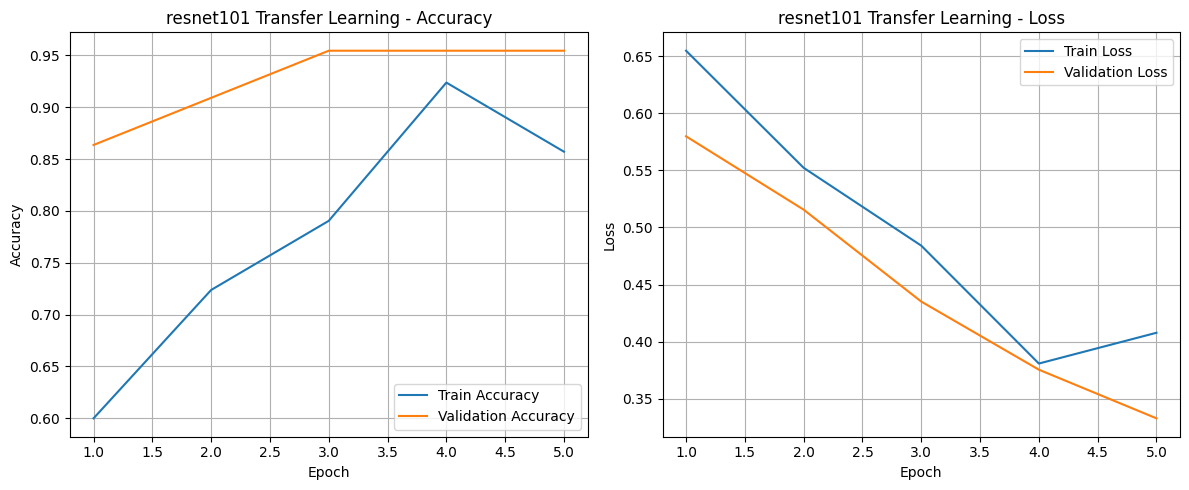


Training model: mobilenet
Total parameters: 4204594
Trainable parameters: 2562
Epoch 1/5 | Train Loss: 0.6328 | Val Loss: 0.5576 | Train Acc: 63.81% | Val Acc: 72.73%
Epoch 2/5 | Train Loss: 0.4992 | Val Loss: 0.4411 | Train Acc: 84.76% | Val Acc: 81.82%
Epoch 3/5 | Train Loss: 0.4444 | Val Loss: 0.3876 | Train Acc: 86.67% | Val Acc: 90.91%
Epoch 4/5 | Train Loss: 0.3837 | Val Loss: 0.3438 | Train Acc: 91.43% | Val Acc: 95.45%
Epoch 5/5 | Train Loss: 0.3426 | Val Loss: 0.2977 | Train Acc: 89.52% | Val Acc: 100.00%
Test Loss: 0.2802
Test Accuracy: 100.0 %


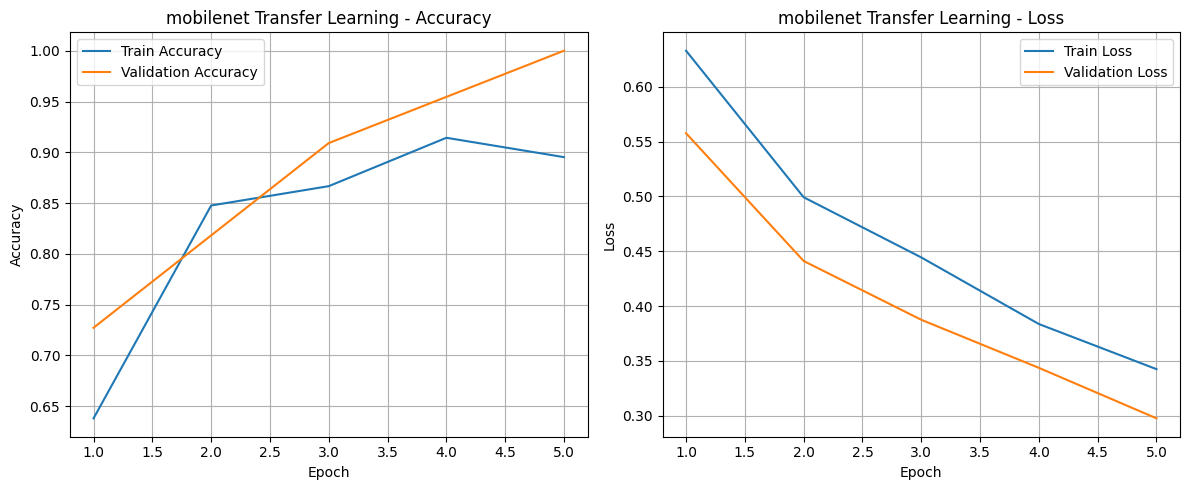

,Model,Trainable Parameters,Final Train Acc,Final Val Acc,Test Accuracy,Test Loss,Training Time (s)
0,vgg16,8194,0.904762,0.863636,0.826087,0.339072,19.561258
1,resnet50,4098,0.923810,1.000000,0.956522,0.386335,16.611914
2,alexnet,8194,0.980952,0.909091,0.913043,0.170418,20.762243
3,resnet101,4098,0.857143,0.954545,0.956522,0.340041,23.097612
4,mobilenet,2562,0.895238,1.000000,1.000000,0.280186,21.379912


In [12]:
TRANSFER_EPOCHS = 5
TRANSFER_LR = 0.001

models_to_train = [
    "vgg16",
    "resnet50",
    "alexnet",
    "resnet101",
    "mobilenet"
]

transfer_results = []
trained_models = {}
training_histories = {}

for model_name in models_to_train:
    print("\n" + "=" * 60)
    print("Training model:", model_name)
    print("=" * 60)

    torch.manual_seed(SEED)

    model = build_transfer_model(model_name, num_classes)

    print("Total parameters:", count_total_parameters(model))
    print("Trainable parameters:", count_trainable_parameters(model))

    history, training_time = train_transfer_model(
        model,
        train_loader,
        val_loader,
        epochs=TRANSFER_EPOCHS,
        learning_rate=TRANSFER_LR
    )

    criterion = nn.CrossEntropyLoss()
    test_loss, test_accuracy = evaluate_model(model, test_loader, criterion)

    print("Test Loss:", round(test_loss, 4))
    print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

    transfer_results.append({
        "Model": model_name,
        "Trainable Parameters": count_trainable_parameters(model),
        "Final Train Acc": history["train_accuracy"][-1],
        "Final Val Acc": history["val_accuracy"][-1],
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss,
        "Training Time (s)": training_time
    })

    trained_models[model_name] = model
    training_histories[model_name] = history

    plot_training_history(
        history,
        title=f"{model_name} Transfer Learning",
        filename=f"images/tutorial_06_{model_name}_training_curves.png"
    )

transfer_results_df = pd.DataFrame(transfer_results)
transfer_results_df


## 12. Save Transfer Learning Comparison Table

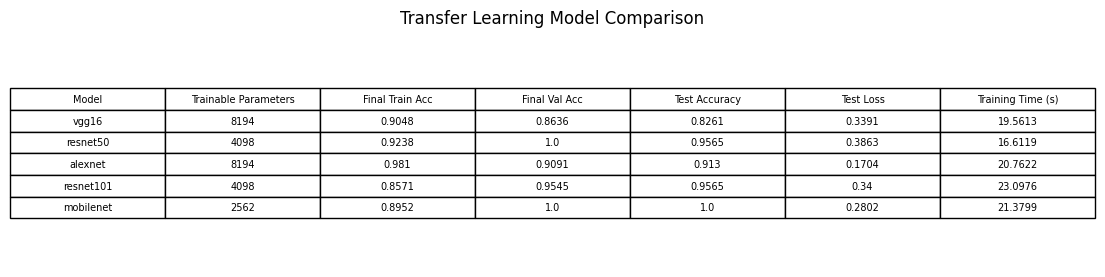

In [13]:
transfer_results_image_df = transfer_results_df.copy()

for column in ["Final Train Acc", "Final Val Acc", "Test Accuracy", "Test Loss", "Training Time (s)"]:
    transfer_results_image_df[column] = transfer_results_image_df[column].round(4)

save_dataframe_as_image(
    transfer_results_image_df,
    "images/tutorial_06_transfer_learning_comparison_table.png",
    title="Transfer Learning Model Comparison",
    fontsize=7
)


## 13. Compare Test Accuracy

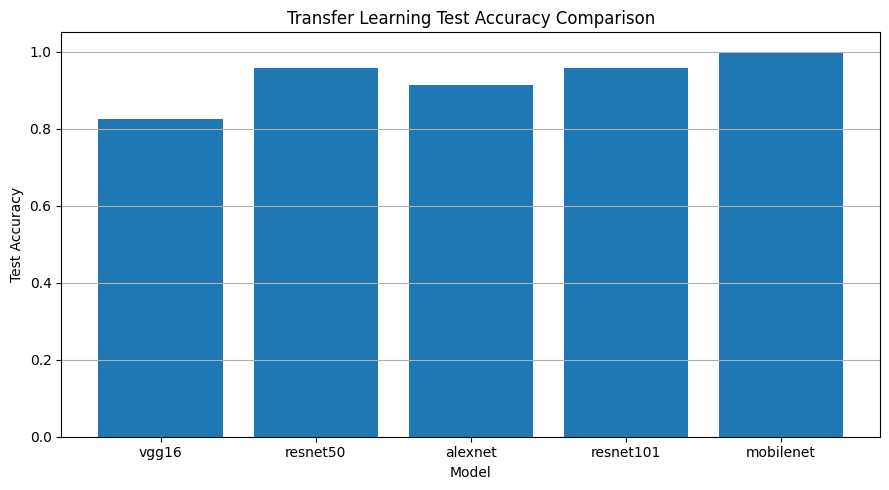

In [14]:
plt.figure(figsize=(9, 5))
plt.bar(transfer_results_df["Model"], transfer_results_df["Test Accuracy"])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Transfer Learning Test Accuracy Comparison")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("images/tutorial_06_transfer_learning_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. Best Model Evaluation

In [15]:
best_row = transfer_results_df.sort_values(by="Test Accuracy", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print(best_row)

y_true, y_pred = get_predictions(best_model, test_loader)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Best model: mobilenet
Model                   mobilenet
Trainable Parameters         2562
Final Train Acc          0.895238
Final Val Acc                 1.0
Test Accuracy                 1.0
Test Loss                0.280186
Training Time (s)       21.379912
Name: 4, dtype: object

Classification Report:
              precision    recall  f1-score   support

      furina       1.00      1.00      1.00         9
      ororon       1.00      1.00      1.00        14

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



## 15. Confusion Matrix

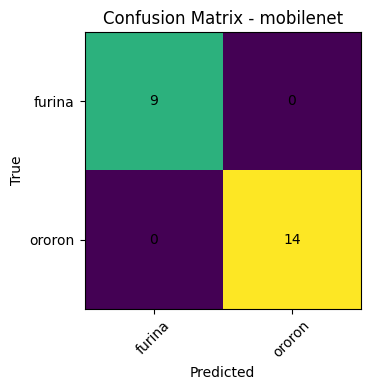

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("images/tutorial_06_best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


## 16. Visualize Best Model Predictions

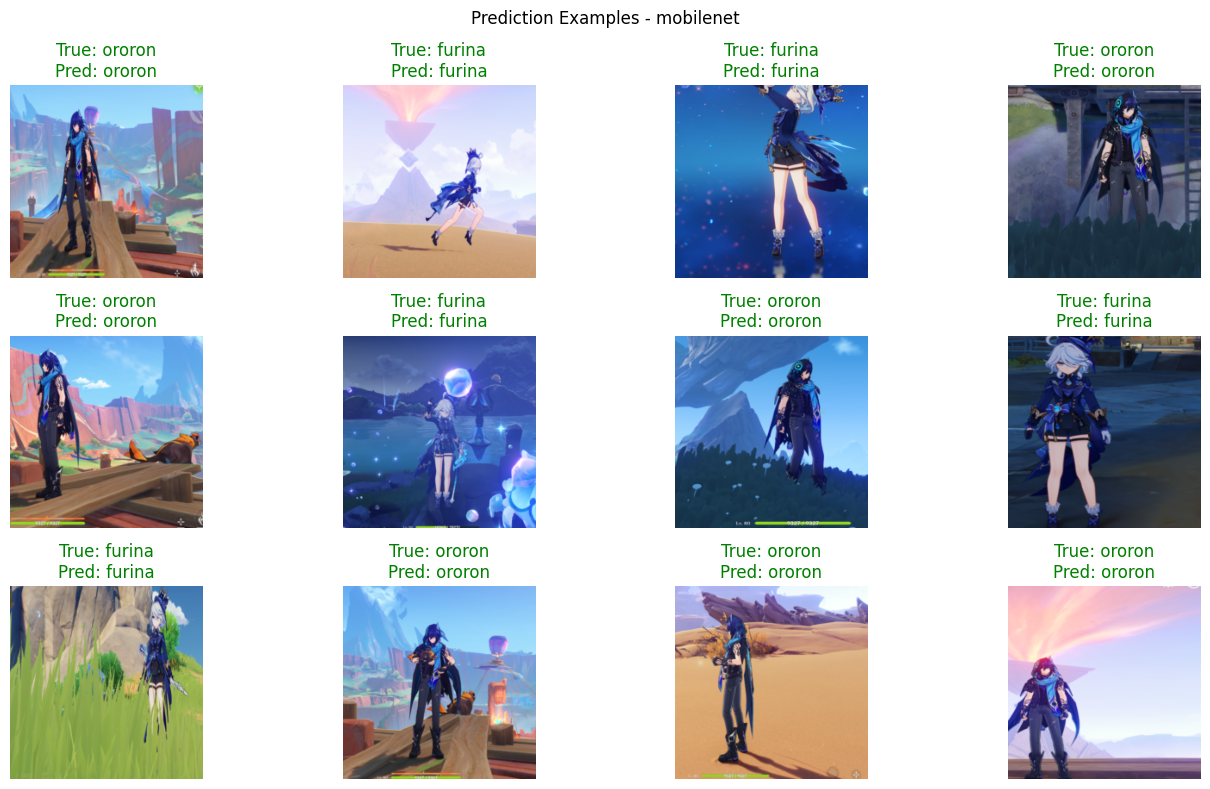

In [17]:
def unnormalize_image(tensor_image):
    image = tensor_image.clone()

    for channel, mean, std in zip(image, imagenet_mean, imagenet_std):
        channel.mul_(std).add_(mean)

    image = torch.clamp(image, 0, 1)

    return image


def visualize_predictions(model, dataset, filename, n_images=12):
    model.eval()

    plt.figure(figsize=(14, 8))

    n_images = min(n_images, len(dataset))

    for i in range(n_images):
        image, true_label = dataset[i]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted_label = torch.max(output, 1)

        image_display = unnormalize_image(image)

        color = "green" if predicted_label.item() == true_label else "red"

        plt.subplot(3, 4, i + 1)
        plt.imshow(image_display.permute(1, 2, 0).numpy())
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[predicted_label.item()]}",
            color=color
        )
        plt.axis("off")

    plt.suptitle(f"Prediction Examples - {best_model_name}")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


visualize_predictions(
    best_model,
    test_dataset,
    filename="images/tutorial_06_best_model_prediction_examples.png",
    n_images=12
)


# Final Observations

## Pretrained Prediction

The ImageNet pretrained models predicted top-5 ImageNet labels for a sample image.  
Since ImageNet does not contain `furina` or `ororon` as classes, these predictions are only used to demonstrate pretrained inference.

## Transfer Learning

For the custom dataset, the final classification layer of each pretrained model was replaced with a new layer for two classes:

- furina
- ororon

The pretrained feature extractor was frozen, and only the final classifier layer was trained.

## Key Learning

Transfer learning allows a model trained on a large dataset such as ImageNet to be adapted to a smaller custom dataset.

This is useful when the custom dataset is small, because the model already contains useful visual features from pretraining.
